# จำนวนมาตราในแต่ละหมวด

นับจำนวนแถวใน `sections_v2.csv` แยกตาม `chapter_title` ซึ่งใช้แทนหมวดของรัฐธรรมนูญ

In [1]:
pip install Path matplotlib pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,หมวด,จำนวน
0,บททั่วไป,1122
1,ไม่ระบุหมวด,358
2,คณะรัฐมนตรี,170
3,พระมหากษัตริย์,166
4,สิทธิและเสรีภาพของชนชาวไทย,158
5,แนวนโยบายแห่งรัฐ,132
6,บทเฉพาะกาล,80
7,อำนาจบริหาร,77
8,มาตรา 17 รัฐสภาประกอบด้วยพฤษฎล วุฒิสภาผู้แทนไม...,51
9,หน้าที่ของชนชาวไทย,50


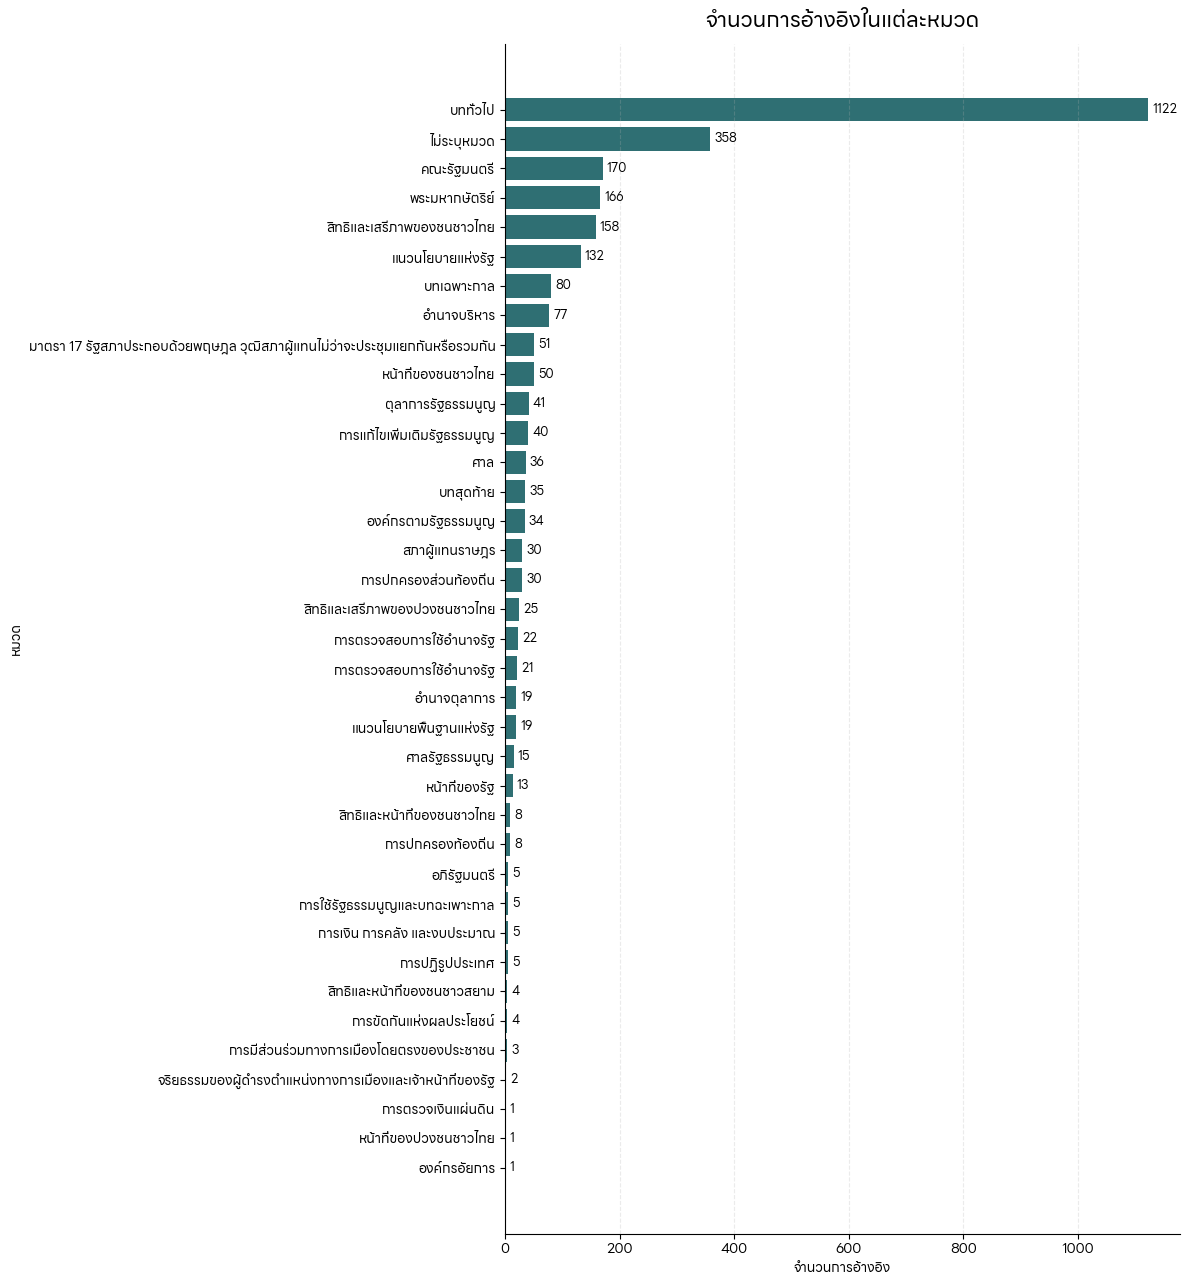

In [2]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd


csv_path = Path("../output/sections_v2.csv")
if not csv_path.exists():
    csv_path = Path("03_data_preparation/output/sections_v2.csv")

df = pd.read_csv(csv_path)

category_counts = (
    df["chapter_title"]
    .fillna("ไม่ระบุหมวด")
    .value_counts()
    .rename_axis("หมวด")
    .reset_index(name="จำนวน")
)

display(category_counts)

font_paths = [
    Path("../../static/font/LINESeedSansTH_Rg.ttf"),
    Path("static/font/LINESeedSansTH_Rg.ttf"),
]
font_path = next((path for path in font_paths if path.exists()), None)
if font_path is not None:
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

plot_data = category_counts.sort_values("จำนวน", ascending=True)
fig_height = max(6, len(plot_data) * 0.35)

fig, ax = plt.subplots(figsize=(12, fig_height))
ax.barh(plot_data["หมวด"], plot_data["จำนวน"], color="#2f6f73")
ax.set_title("จำนวนการอ้างอิงในแต่ละหมวด", fontsize=16, pad=12)
ax.set_xlabel("จำนวนการอ้างอิง")
ax.set_ylabel("หมวด")
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()